In [ ]:
import pandas as pd

df = pd.read_csv('HR.csv',sep=',')
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


In [ ]:
df.drop(['EmployeeCount','StandardHours','Over18'], axis=1, inplace=True)

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


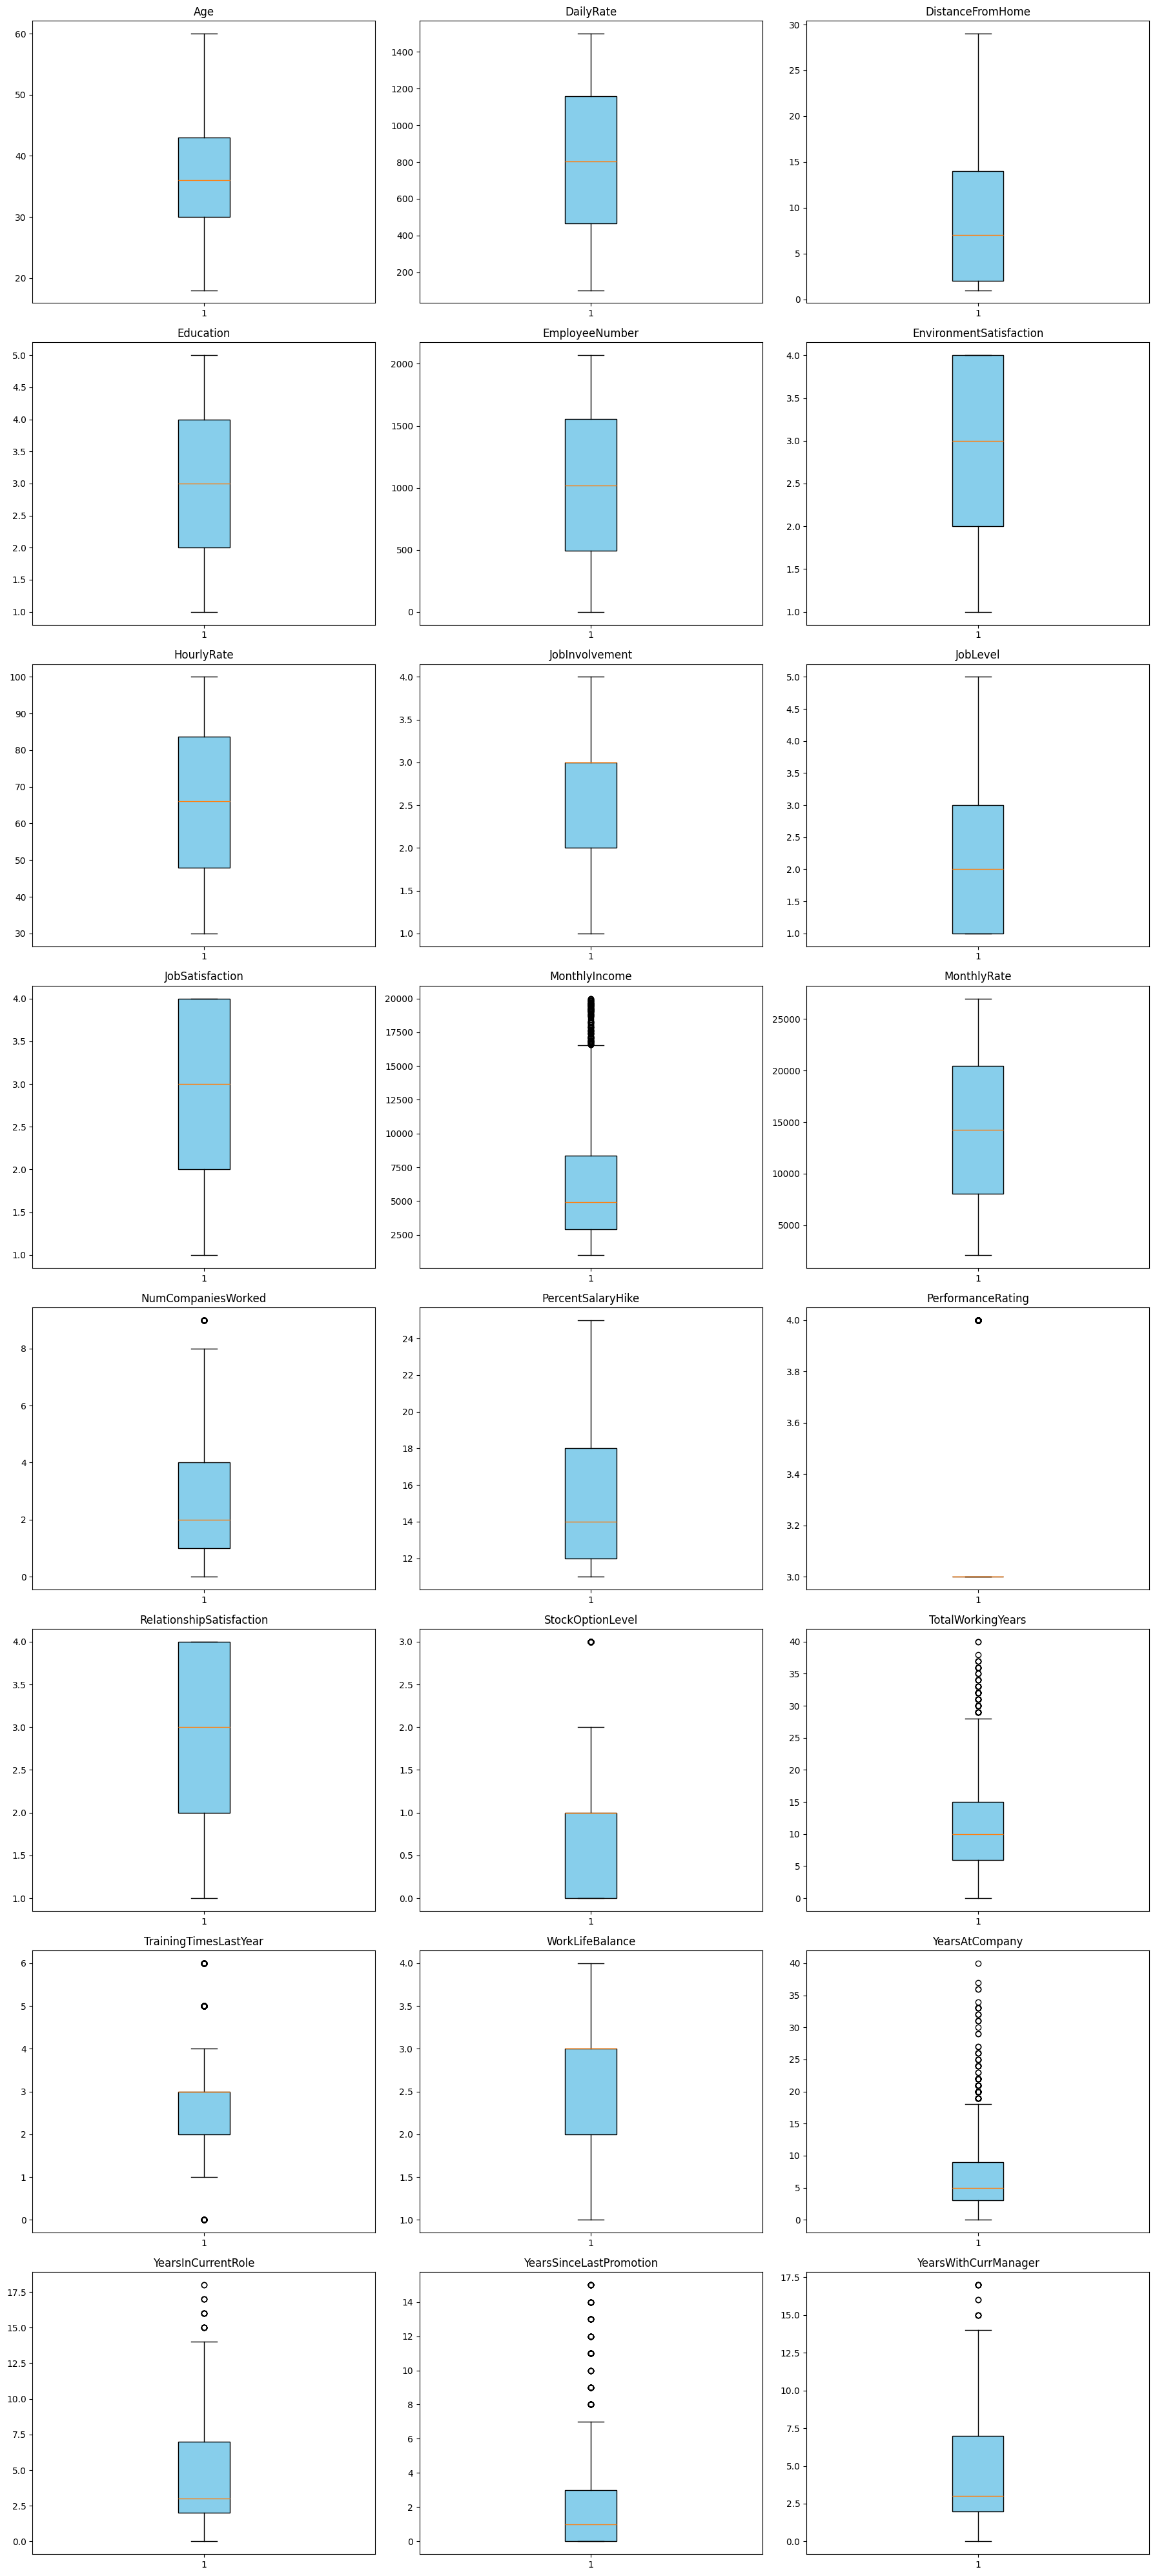

In [ ]:
import matplotlib.pyplot as plt
import math

cols_numeriques = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = math.ceil(len(cols_numeriques) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols_numeriques):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(df[col], patch_artist=True,
                boxprops=dict(facecolor='skyblue'))
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
df[cols_numeriques].mean()

,0
Age,36.923810
DailyRate,802.485714
DistanceFromHome,9.192517
Education,2.912925
EmployeeNumber,1024.865306
EnvironmentSatisfaction,2.721769
HourlyRate,65.891156
JobInvolvement,2.729932
JobLevel,2.063946
JobSatisfaction,2.728571


In [ ]:
df[cols_numeriques].std()

,0
Age,9.135373
DailyRate,403.509100
DistanceFromHome,8.106864
Education,1.024165
EmployeeNumber,602.024335
EnvironmentSatisfaction,1.093082
HourlyRate,20.329428
JobInvolvement,0.711561
JobLevel,1.106940
JobSatisfaction,1.102846


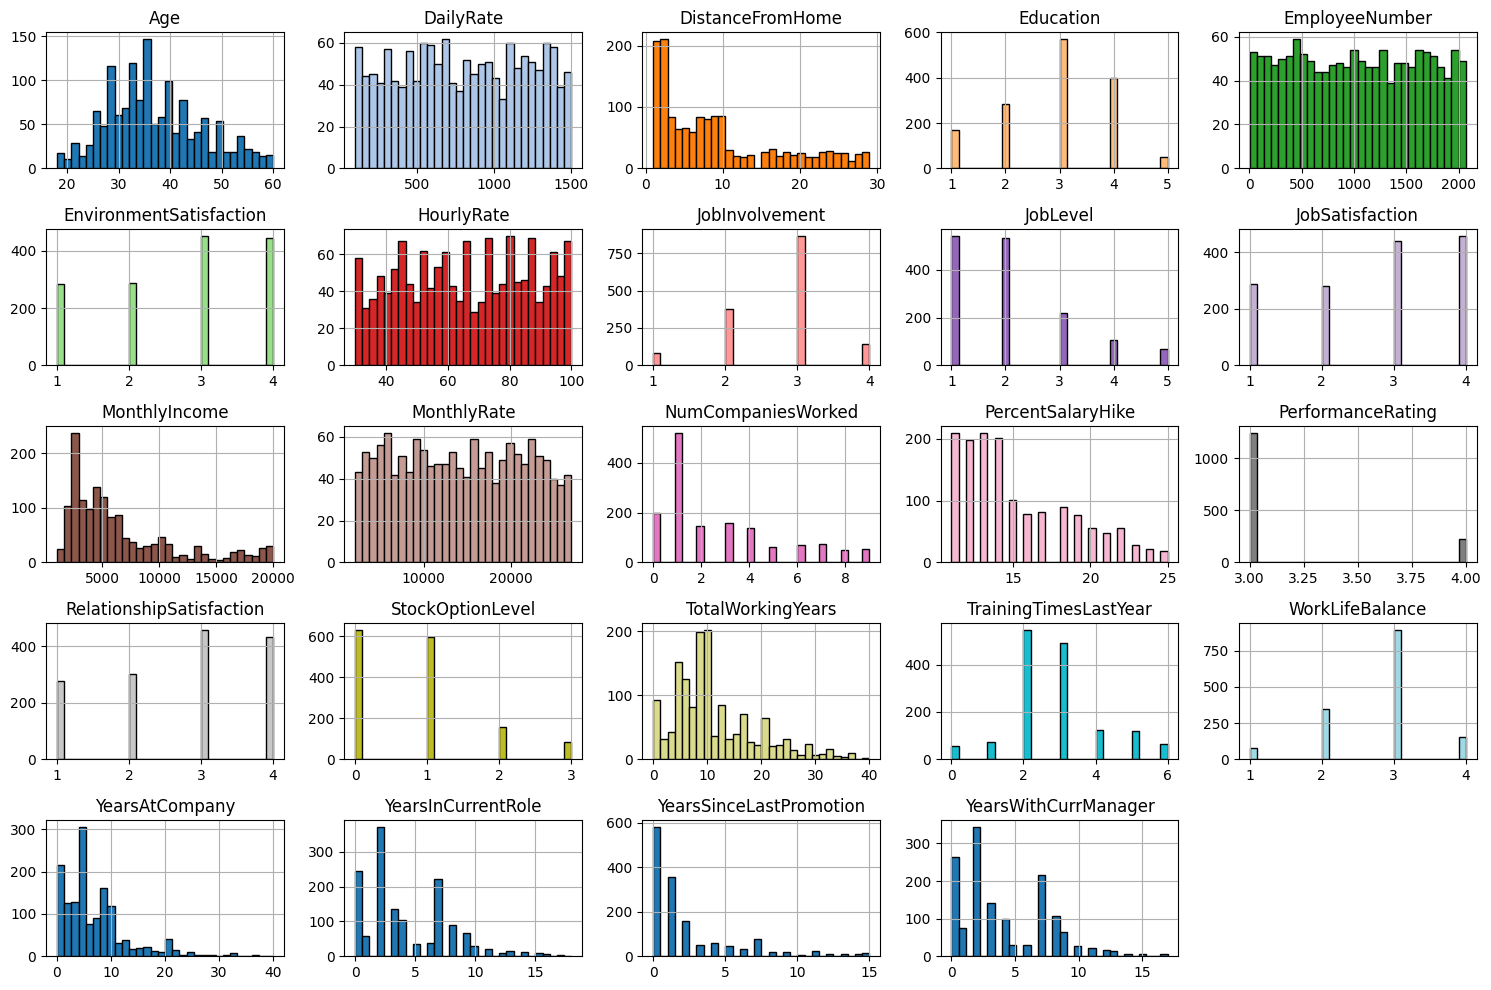

In [ ]:
#visualisation de data
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.tab20.colors

axes = df[cols_numeriques].hist(
    bins=30,
    figsize=(15,10),
    edgecolor='black'
)

for ax, color in zip(axes.flatten(), colors):
    for patch in ax.patches:
        patch.set_facecolor(color)

plt.tight_layout()
plt.show()

In [ ]:
#Vérifier l’asymétrie
print(df[cols_numeriques].skew())

Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EmployeeNumber              0.016574
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.369817
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.764529
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: float64


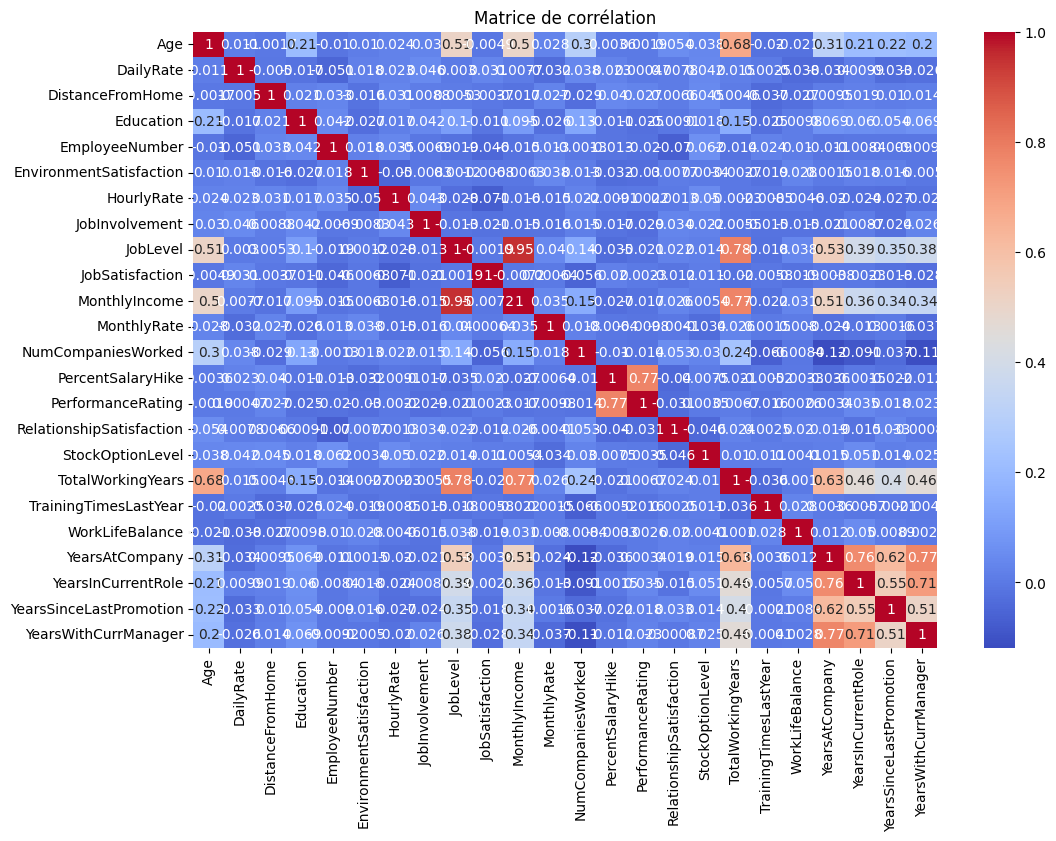

In [ ]:
#matrice de correlation


plt.figure(figsize=(12,8))
sns.heatmap(df[cols_numeriques].corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
#transformer de la variable cible
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Attrition', axis=1)

y = df['Attrition']

# Colonnes numériques sauf target
num_cols = df.drop('Attrition', axis=1).select_dtypes(include=['int64','float64']).columns

# Normalisation seulement sur les features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [ ]:
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.446350,1,Travel_Rarely,0.742527,Sales,-1.010909,-0.891688,Life Sciences,-1.701283,-0.660531,...,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834
1,1.322365,0,Travel_Frequently,-1.297775,Research & Development,-0.147150,-1.868426,Life Sciences,-1.699621,0.254625,...,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541
2,0.008343,1,Travel_Rarely,1.414363,Research & Development,-0.887515,-0.891688,Other,-1.696298,1.169781,...,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1176, 45)
Test size: (294, 45)


In [ ]:
#arbre de decision
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
tree_model = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)

# Entraîner
tree_model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=3, random_state=42)

=== Évaluation sur TEST ===
Accuracy : 0.8367346938775511

Classification Report :
               precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.48      0.21      0.29        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.60       294
weighted avg       0.80      0.84      0.81       294



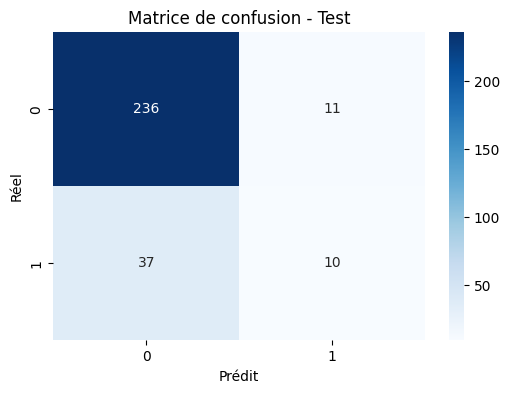

=== Évaluation sur TRAIN ===
Accuracy : 0.8673469387755102

Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       986
           1       0.70      0.31      0.43       190

    accuracy                           0.87      1176
   macro avg       0.79      0.64      0.68      1176
weighted avg       0.85      0.87      0.85      1176



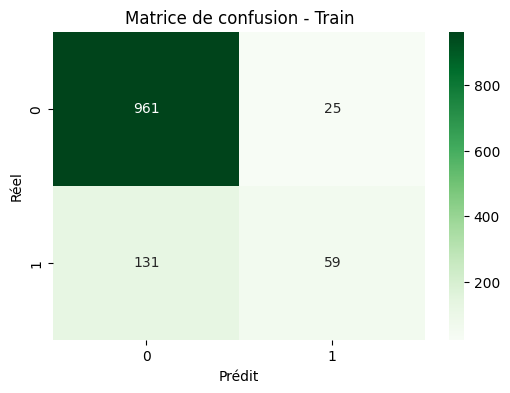

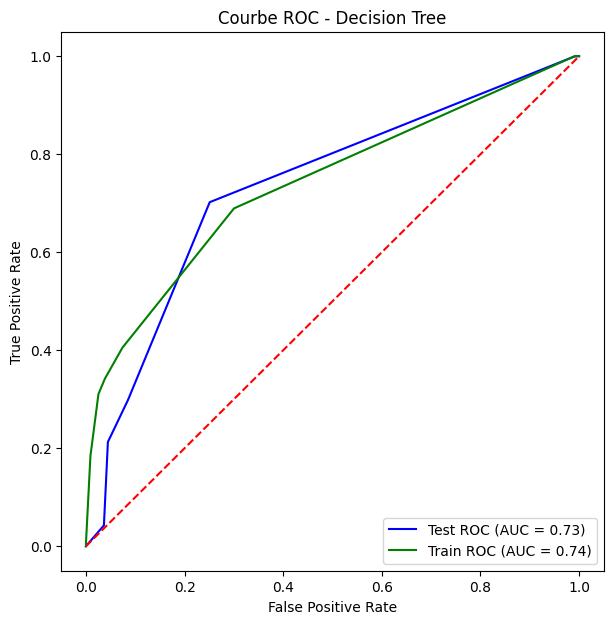

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prédiction ---
y_pred_test = tree_model.predict(X_test)
y_pred_train = tree_model.predict(X_train)

# --- Évaluation Test ---
print("=== Évaluation sur TEST ===")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("\nClassification Report :\n", classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Test")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# --- Évaluation Train ---
print("=== Évaluation sur TRAIN ===")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print("\nClassification Report :\n", classification_report(y_train, y_pred_train))

cm_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion - Train")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# --- Courbe ROC ---
y_prob_test = tree_model.predict_proba(X_test)[:,1]
y_prob_train = tree_model.predict_proba(X_train)[:,1]

fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
auc_test = roc_auc_score(y_test, y_prob_test)

fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
auc_train = roc_auc_score(y_train, y_prob_train)

plt.figure(figsize=(7,7))
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.2f})', color='blue')
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.2f})', color='green')
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - Decision Tree')
plt.legend(loc='lower right')
plt.show()



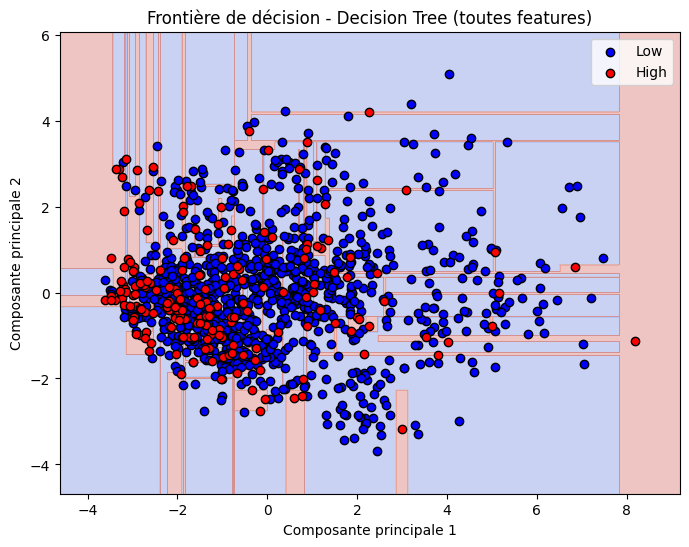

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

#  Entraîner le modèle sur toutes les features
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)  # Toutes les features utilisées ici

#  Réduction PCA pour visualiser
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Ré-entrainement juste pour tracer la frontière sur PCA
dtree_pca = DecisionTreeClassifier(random_state=42)
dtree_pca.fit(X_train_pca, y_train)

#  Créer la grille pour la visualisation
x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = dtree_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#  Tracer la frontière
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_pca[y_train==0,0], X_train_pca[y_train==0,1], c='blue', label='Low', edgecolor='k')
plt.scatter(X_train_pca[y_train==1,0], X_train_pca[y_train==1,1], c='red', label='High', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Decision Tree (toutes features)")
plt.legend()
plt.show()

=== TRAIN ===
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



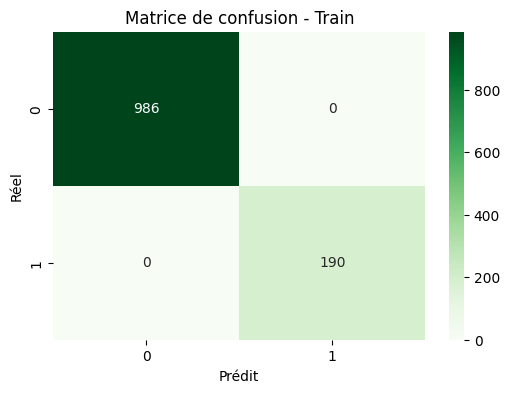

=== TEST ===
Accuracy : 0.7959183673469388
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       247
           1       0.37      0.38      0.38        47

    accuracy                           0.80       294
   macro avg       0.62      0.63      0.63       294
weighted avg       0.80      0.80      0.80       294



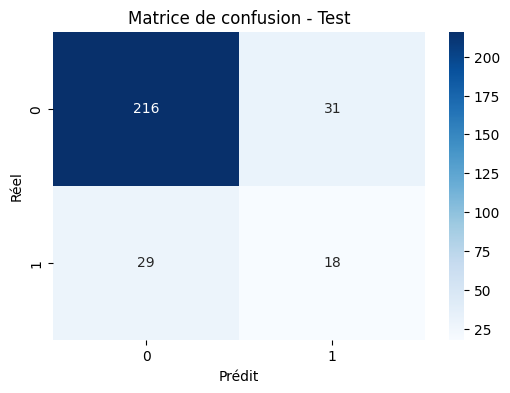

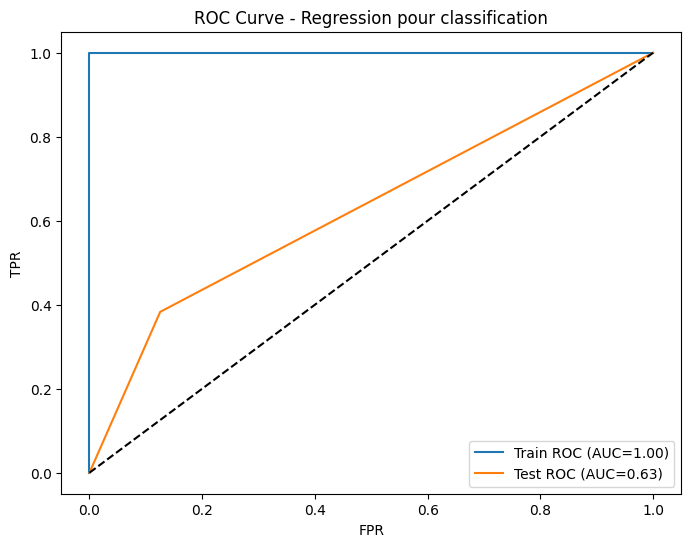

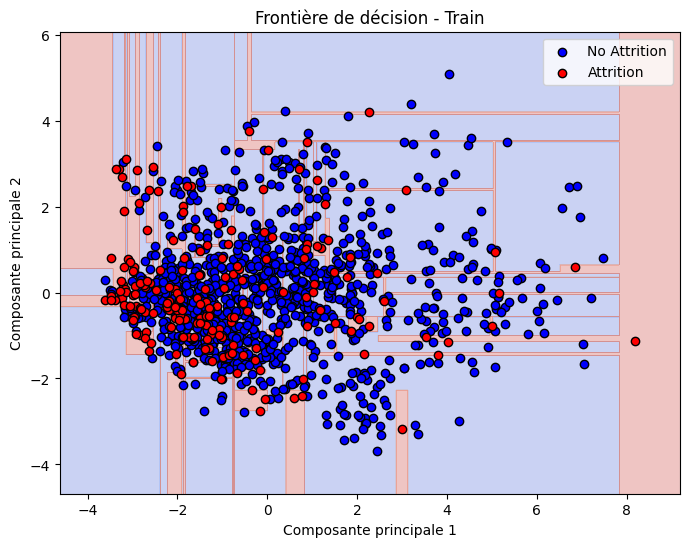

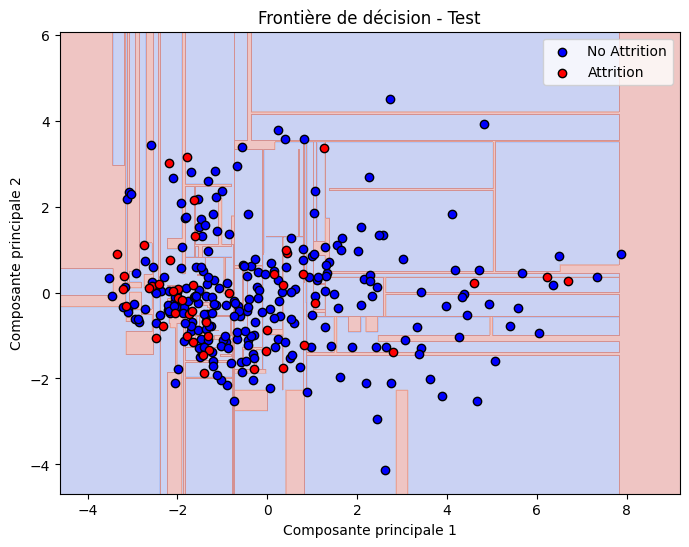

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#  Entraînement du modèle
dtree_reg = DecisionTreeRegressor(random_state=42)
dtree_reg.fit(X_train, y_train)  # y_train contient 0 et 1

#  Prédiction continue
y_pred_train_cont = dtree_reg.predict(X_train)
y_pred_test_cont = dtree_reg.predict(X_test)

#  Conversion en classes
y_pred_train = (y_pred_train_cont > 0.5).astype(int)
y_pred_test = (y_pred_test_cont > 0.5).astype(int)

#  Évaluation train
print("=== TRAIN ===")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

cm_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion - Train")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

#  Évaluation test
print("=== TEST ===")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Test")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

#  ROC et AUC
y_prob_train = y_pred_train_cont  # valeurs continues pour ROC
y_prob_test = y_pred_test_cont

fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={auc_train:.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC={auc_test:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Regression pour classification")
plt.legend()
plt.show()

#  Visualisation frontière via PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Ré-entraîner un petit arbre sur les 2 composantes PCA
dtree_pca = DecisionTreeRegressor(random_state=42)
dtree_pca.fit(X_train_pca, y_train)

# Grille pour visualisation
x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = dtree_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Affichage train
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[y_train==0,0], X_train_pca[y_train==0,1], c='blue', label='No Attrition', edgecolor='k')
plt.scatter(X_train_pca[y_train==1,0], X_train_pca[y_train==1,1], c='red', label='Attrition', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Train")
plt.legend()
plt.show()

# Affichage test
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[y_test==0,0], X_test_pca[y_test==0,1], c='blue', label='No Attrition', edgecolor='k')
plt.scatter(X_test_pca[y_test==1,0], X_test_pca[y_test==1,1], c='red', label='Attrition', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Test")
plt.legend()
plt.show()

=== TRAIN ===
Accuracy : 0.9141156462585034
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       986
           1       1.00      0.47      0.64       190

    accuracy                           0.91      1176
   macro avg       0.95      0.73      0.79      1176
weighted avg       0.92      0.91      0.90      1176



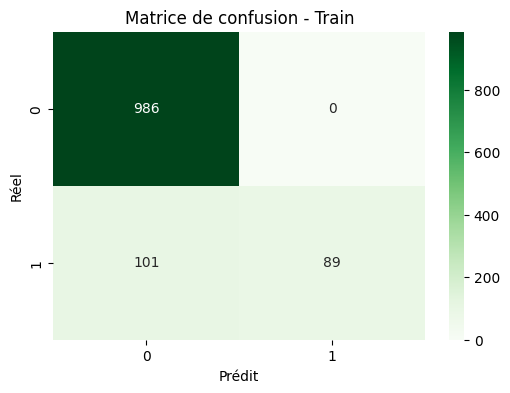

=== TEST ===
Accuracy : 0.8673469387755102
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       247
           1       0.90      0.19      0.32        47

    accuracy                           0.87       294
   macro avg       0.88      0.59      0.62       294
weighted avg       0.87      0.87      0.83       294



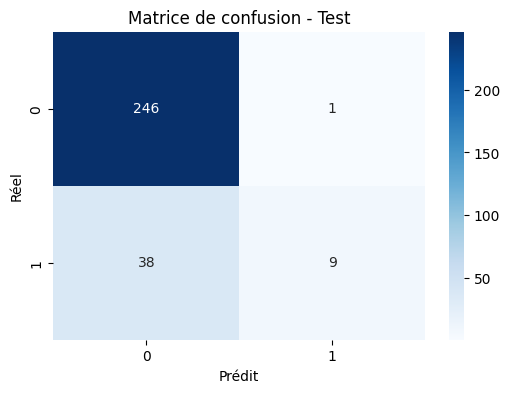

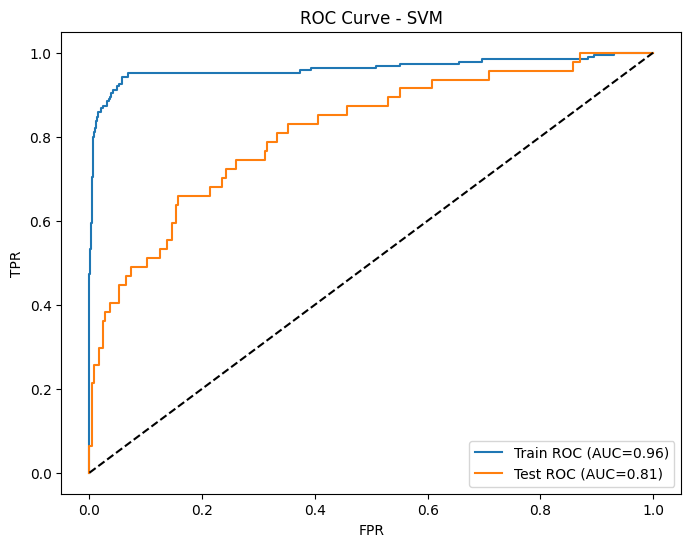

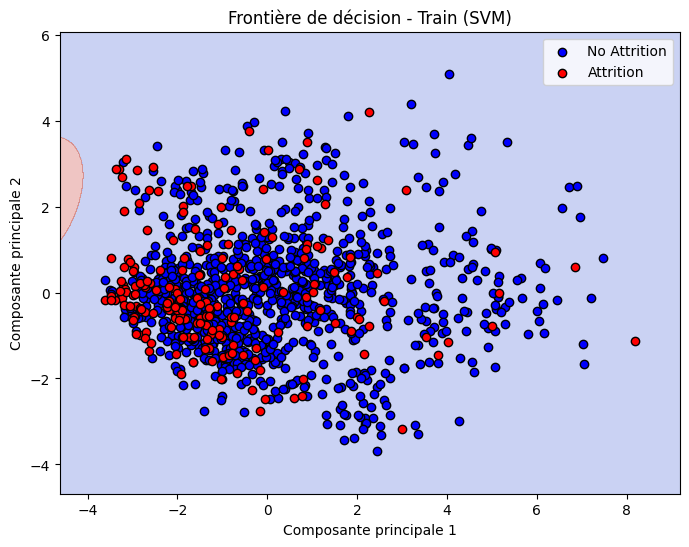

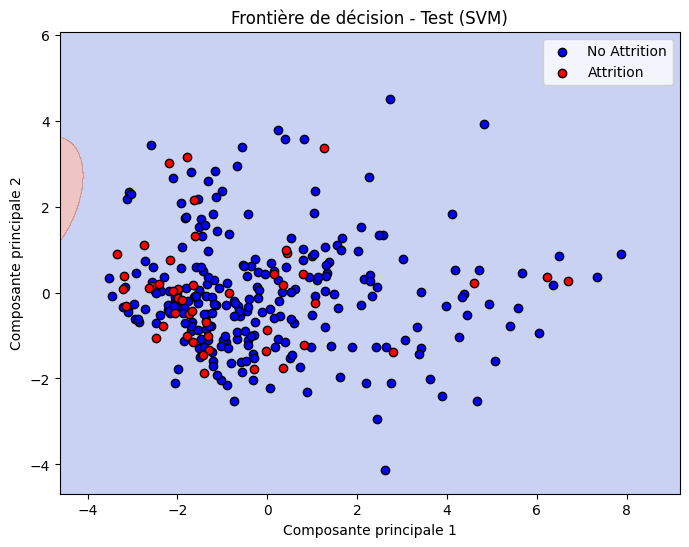

In [ ]:
#svm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#  Entraînement du modèle SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)  # toutes les features

#  Prédiction classes
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

#  Évaluation train
print("=== TRAIN ===")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

cm_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion - Train")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

#  Évaluation test
print("=== TEST ===")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Test")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

#  ROC et AUC
y_prob_train = svm_model.predict_proba(X_train)[:,1]  # probabilité pour la classe 1
y_prob_test = svm_model.predict_proba(X_test)[:,1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={auc_train:.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC={auc_test:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

#  Visualisation frontière via PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Ré-entraîner un SVM sur les 2 composantes PCA pour tracer la frontière
svm_pca = SVC(kernel='rbf', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Grille pour visualisation
x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Affichage train
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[y_train==0,0], X_train_pca[y_train==0,1], c='blue', label='No Attrition', edgecolor='k')
plt.scatter(X_train_pca[y_train==1,0], X_train_pca[y_train==1,1], c='red', label='Attrition', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Train (SVM)")
plt.legend()
plt.show()

# Affichage test
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[y_test==0,0], X_test_pca[y_test==0,1], c='blue', label='No Attrition', edgecolor='k')
plt.scatter(X_test_pca[y_test==1,0], X_test_pca[y_test==1,1], c='red', label='Attrition', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Test (SVM)")
plt.legend()
plt.show()

=== TRAIN ===
Accuracy : 0.8801020408163265
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       986
           1       0.89      0.29      0.44       190

    accuracy                           0.88      1176
   macro avg       0.88      0.64      0.69      1176
weighted avg       0.88      0.88      0.85      1176



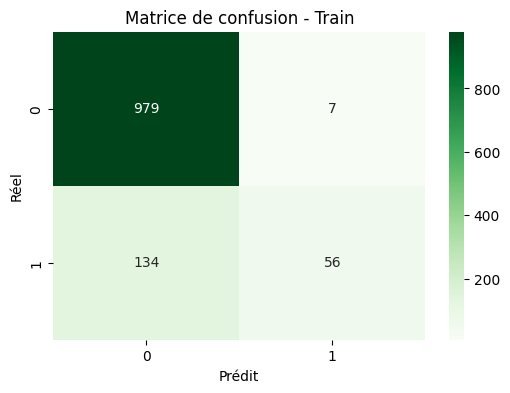

=== TEST ===
Accuracy : 0.8231292517006803
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.31      0.09      0.13        47

    accuracy                           0.82       294
   macro avg       0.58      0.52      0.52       294
weighted avg       0.76      0.82      0.78       294



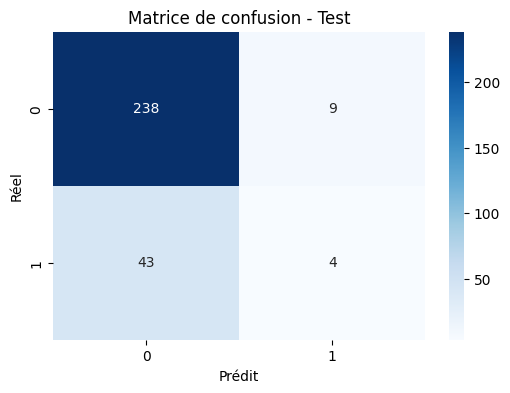

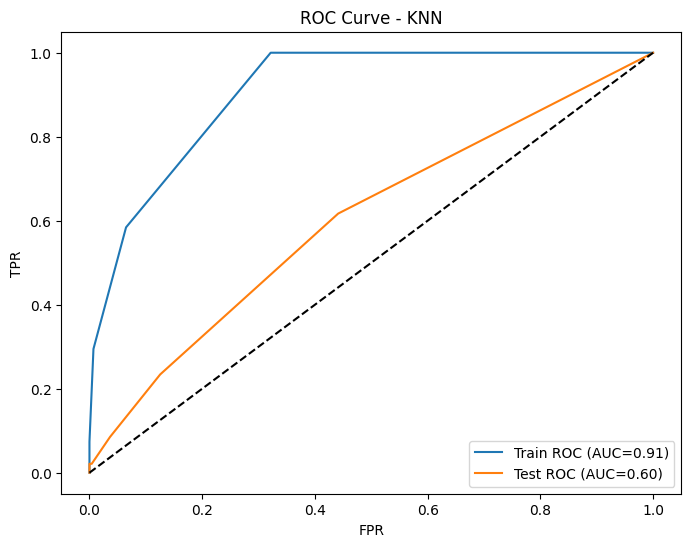

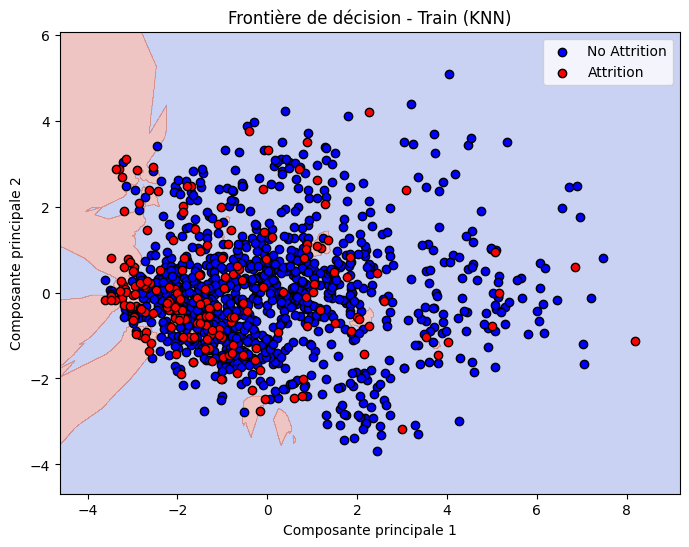

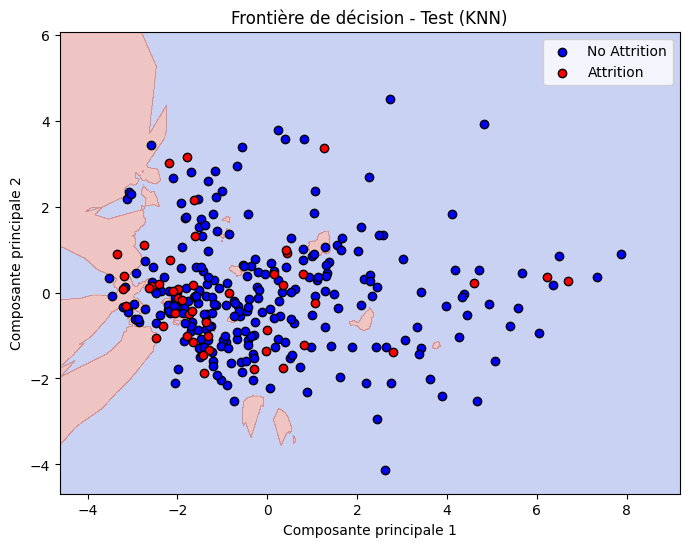

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------- Entraînement du modèle KNN ---------
knn_model = KNeighborsClassifier(n_neighbors=5)  # tu peux changer k
knn_model.fit(X_train, y_train)

# --------- Prédiction classes ---------
y_pred_train = knn_model.predict(X_train)
y_pred_test = knn_model.predict(X_test)

# --------- Évaluation train ---------
print("=== TRAIN ===")
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

cm_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion - Train")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# --------- Évaluation test ---------
print("=== TEST ===")
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Test")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# --------- ROC et AUC ---------
y_prob_train = knn_model.predict_proba(X_train)[:,1]  # probabilité pour la classe 1
y_prob_test = knn_model.predict_proba(X_test)[:,1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={auc_train:.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC={auc_test:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

# --------- Visualisation frontière via PCA ---------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Ré-entraîner KNN sur 2 composantes PCA pour visualiser la frontière
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

# Grille pour visualisation
x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Affichage train
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[y_train==0,0], X_train_pca[y_train==0,1], c='blue', label='No Attrition', edgecolor='k')
plt.scatter(X_train_pca[y_train==1,0], X_train_pca[y_train==1,1], c='red', label='Attrition', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Train (KNN)")
plt.legend()
plt.show()

# Affichage test
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[y_test==0,0], X_test_pca[y_test==0,1], c='blue', label='No Attrition', edgecolor='k')
plt.scatter(X_test_pca[y_test==1,0], X_test_pca[y_test==1,1], c='red', label='Attrition', edgecolor='k')
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Frontière de décision - Test (KNN)")
plt.legend()
plt.show()

In [ ]:
# Si ton modèle a été entraîné sur X_encoded
print(X_encoded.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married

In [ ]:
import pandas as pd

# Crée un dictionnaire avec toutes les colonnes
new_data_dict = {col: [0] for col in X_encoded.columns}  # init toutes les colonnes à 0

# Remplir les valeurs numériques
new_data_dict['Age'] = [40]
new_data_dict['DailyRate'] = [8000]
new_data_dict['DistanceFromHome'] = [9]
new_data_dict['Education'] = [3]
new_data_dict['EnvironmentSatisfaction'] = [9]
new_data_dict['JobSatisfaction'] = [3]
new_data_dict['MonthlyRate'] = [4000]
new_data_dict['TotalWorkingYears'] = [8]
new_data_dict['TrainingTimesLastYear'] = [6]
new_data_dict['YearsAtCompany'] = [12]
new_data_dict['YearsInCurrentRole'] = [5]
new_data_dict['YearsSinceLastPromotion'] = [1]
new_data_dict['YearsWithCurrManager'] = [3]

# Remplir les colonnes catégorielles (OneHot)
new_data_dict['BusinessTravel_Travel_Rarely'] = [0]
new_data_dict['Department_Sales'] = [0]
new_data_dict['EducationField_Life Sciences'] = [0]
new_data_dict['Gender_Male'] = [0]
new_data_dict['JobRole_Sales Executive'] = [0]
new_data_dict['MaritalStatus_Single'] = [0]
new_data_dict['OverTime_Yes'] = [0]

# Crée le DataFrame
new_instance = pd.DataFrame(new_data_dict)

#  Prédiction
y_new_pred = tree_model.predict(new_instance)
print("Classe prédite ADD:", y_new_pred[0])
y_new_pred = svm_model.predict(new_instance)
print("Classe prédite SVM :", y_new_pred[0])


Classe prédite ADD: 0
Classe prédite SVM : 0
